### Imports

In [350]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import cross_validate

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


from sklearn.preprocessing import StandardScaler,PowerTransformer,PowerTransformer,RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline

### Utility function

In [351]:
def regression_report(predicted, true):
    mean_squared_error_value = mean_squared_error(true, predicted)
    mean_absolute_error_value = mean_absolute_error(true, predicted)
    r2_score_value = r2_score(true, predicted)
    root_mean_squared_error_value = root_mean_squared_error(true, predicted)

    print("="*50)
    print("       Regression performance report" )
    print("="*50)
    print(
    "   Mean squared error: ",  np.round(mean_squared_error_value, 3), "\n"
    "   Mean absolute error:",  np.round(mean_absolute_error_value, 3), "\n"
    "   Root mean squared error:",             np.round(root_mean_squared_error_value, 3), "\n"
    "   R2 score:",             np.round(r2_score_value, 3)
    )
    print("="*50)


In [352]:
def plot_actual_predicted(true, predicted):
    true = np.ravel(true)
    predicted = np.ravel(predicted)

    plt.figure(figsize=(8,6))

    sns.scatterplot(x=true, y=predicted, alpha=0.7, edgecolors='k', label="Predictions")

    min_value, max_value = min(true.min(), predicted.min()), max(true.max(), predicted.max())
    plt.plot([min_value, max_value], [min_value, max_value], color="purple", linestyle='--', label="y = x")

    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title("Actual vs Predicted values")
    plt.legend()
    plt.grid(True)


In [353]:
def histogram_residuals(true, predicted):
    residuals = true - predicted
    
    
    plt.figure(figsize=(8, 5))
    sns.histplot(residuals, bins=10, kde=True, color='blue') 
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title("Histogram of Residuals")
    plt.grid(True)
    plt.show()

In [354]:
def plot_qq(residuals):
    plt.figure(figsize=(6, 6))
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title("QQ Plot of Residuals")
    plt.grid(True)
    plt.show()


## Load the non standardized data

In [355]:
X_train = pd.read_csv("x_train_not_standard.csv",index_col=0)
y_train = pd.read_csv("y_train_not_standard.csv" ,index_col=0)

X_test = pd.read_csv("x_test_not_standard.csv",index_col=0)
y_test = pd.read_csv("y_test_not_standard.csv",index_col=0)

#### Basic training

Standardize the data using the StandardScaler

In [356]:
scaler = StandardScaler()

X_train_stand = scaler.fit_transform(X_train)
X_test_stand = scaler.transform(X_test)

y_train_stand = scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_stand = scaler.transform(y_test.values.reshape(-1, 1))

In [357]:
linear_regressor = LinearRegression()

linear_regressor.fit(X_train_stand, y_train_stand)

LinearRegression()

Coefficients of the model

In [358]:
print('Coefficients: \n', linear_regressor.coef_)

Coefficients: 
 [[-4.51083471e-02  1.50445653e-02  1.66297157e-01 -1.97065687e-01
   6.80302274e-02 -8.46658260e-02  1.88310859e-01  1.87697024e+00
  -1.18467367e-01  4.78542539e-02  1.33510289e-01  6.56522499e-01
   6.54119675e-02 -9.67358866e+11 -1.01685420e+12 -4.94016455e-01
  -2.70240591e+11 -8.46071730e-01  1.96750385e+12  2.58467636e-02
   1.22087912e-01 -5.12392091e-02 -1.40231273e-01 -6.71271420e-02
  -7.95686234e-02 -1.30098548e-01 -7.06409717e-02  1.23716989e-02
  -3.48300049e-02 -1.55821010e-01 -9.56585853e-02 -3.79174382e+12
  -1.31094760e-01  8.34581551e-02 -6.70643909e-02  3.44658060e-02
   1.61086789e+12 -1.81055487e-01 -9.75784385e-02 -4.78106646e-02
  -3.30306057e+11  1.28684657e-01 -3.43331496e-02 -7.77528924e-02
  -1.80941849e-01 -1.94859522e-01 -1.44592785e-01  3.61000437e-02
   1.11300769e-01  1.00233699e+12  3.79174382e+12  1.79116375e-03
  -1.87042107e+12 -8.83178071e-02  4.49408536e+10 -1.42210007e+11
  -4.04373600e+11 -1.65142990e+11  7.86400728e+10 -2.4798076

#### Prediction

In [359]:
prediction1 = linear_regressor.predict(X_test_stand)


regression_report(prediction1, y_test_stand)

       Regression performance report
   Mean squared error:  4.038753861348321e+22 
   Mean absolute error: 32180396411.218 
   Root mean squared error: 200966511174.084 
   R2 score: -2.868325445276932e+22


#### Cross validation

In [360]:
scores = cross_validate(linear_regressor, X_train_stand, y_train_stand, cv=5, scoring='r2')
print(f"Training Mean R²: {scores['test_score'].mean():.3f}")

print(f"Test Mean R²:  {r2_score(y_test_stand, prediction1):.3f}")

Training Mean R²: -71005670246776586240.000
Test Mean R²:  -28683254452769320337408.000


#### Visualization

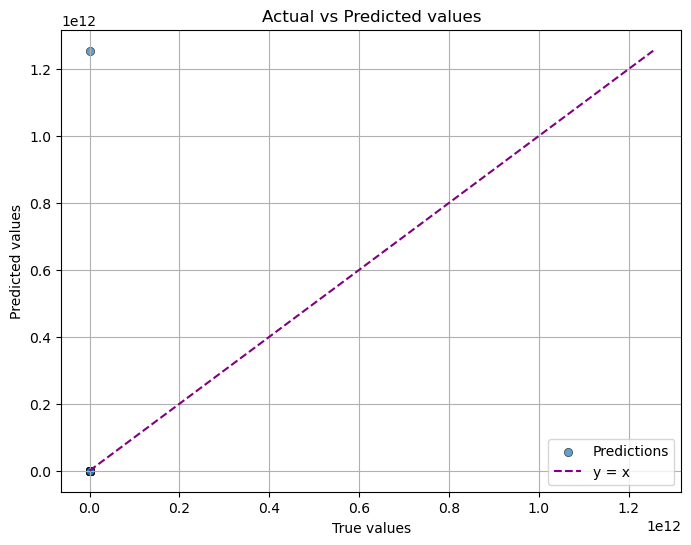

In [361]:
plot_actual_predicted(y_test_stand, prediction1)

This is not good, and the cause of this is the multi colinearity between the features (as indicated in the heatmap of the EDA)

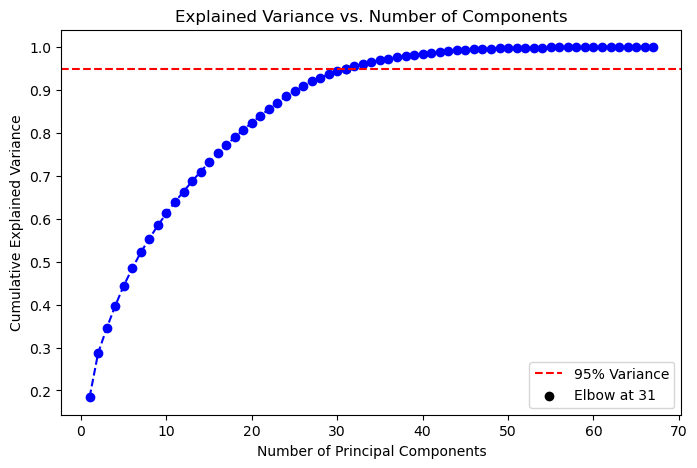

Optimal number of components: 31


In [362]:
pca = PCA()
X_pca = pca.fit_transform(X_train_stand)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

#visualisation

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs. Number of Components")


plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance")


optimal_components = np.argmax(explained_variance >= 0.95) + 1
plt.scatter(optimal_components, explained_variance[optimal_components - 1], color='black', label=f"Elbow at {optimal_components}")
plt.legend()
plt.show()

print(f"Optimal number of components: {optimal_components}")


Applying the PCA

In [363]:
pca = PCA(n_components=31)

X_train_pca = pca.fit_transform(X_train_stand)
X_test_pca = pca.fit_transform(X_test_stand)

In [364]:
linear_regressor.fit(X_train_pca, y_train_stand)
predicted2 = linear_regressor.predict(X_test_pca)

regression_report(predicted2, y_test_stand)

       Regression performance report
   Mean squared error:  0.56 
   Mean absolute error: 0.514 
   Root mean squared error: 0.748 
   R2 score: 0.602


##### Cross validation

In [375]:
scores = cross_validate(linear_regressor, X_train_pca, y_train_stand, cv=5, scoring='r2')
print(f"Training Mean R²: {scores['test_score'].mean():.3f}")

print(f"Test Mean R²:  {r2_score(y_test_stand, predicted2):.3f}")

Training Mean R²: 0.490
Test Mean R²:  0.602


There is an improvement, but there is a sign of underfitting.

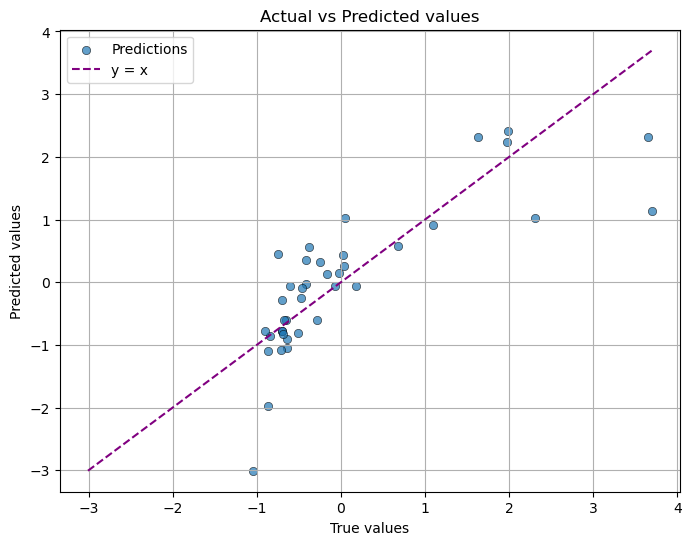

In [ ]:
plot_actual_predicted(y_test_stand, predicted2)

#### Transforming the features

Training CV R²: 0.603
Test R²: 0.431
       Regression performance report
   Mean squared error:  46655806.714 
   Mean absolute error: 2986.522 
   Root mean squared error: 6830.506 
   R2 score: 0.431


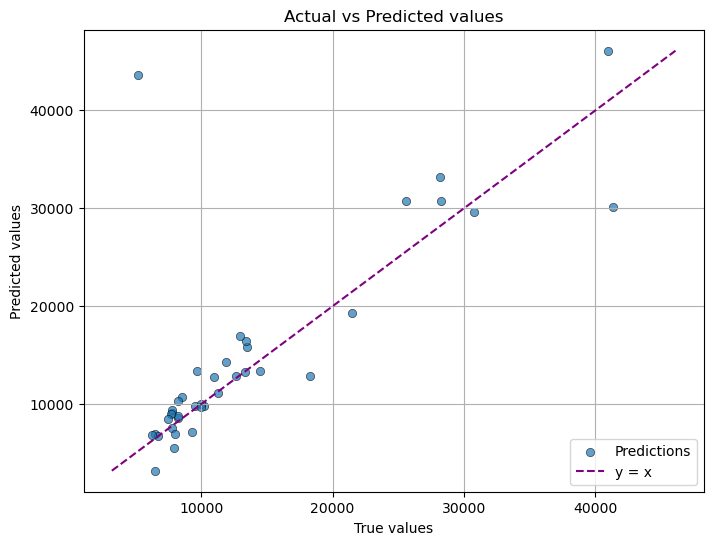

In [367]:
model = make_pipeline(
    PowerTransformer(),
    StandardScaler(),
    LinearRegression()
)

# cross-validate the training
train_scores = cross_validate(model, X_train, y_train, cv=5, scoring='r2')
print(f"Training CV R²: {train_scores['test_score'].mean():.3f}")


model.fit(X_train, y_train)  
test_r2 = model.score(X_test, y_test)
print(f"Test R²: {test_r2:.3f}")


predicted = model.predict(X_test)
regression_report(predicted, y_test)

plot_actual_predicted(y_test, predicted)

### Using Regulization

Training CV R²: 0.881
Test R²: 0.820
       Regression performance report
   Mean squared error:  14778511.364 
   Mean absolute error: 2243.683 
   Root mean squared error: 3844.283 
   R2 score: 0.82


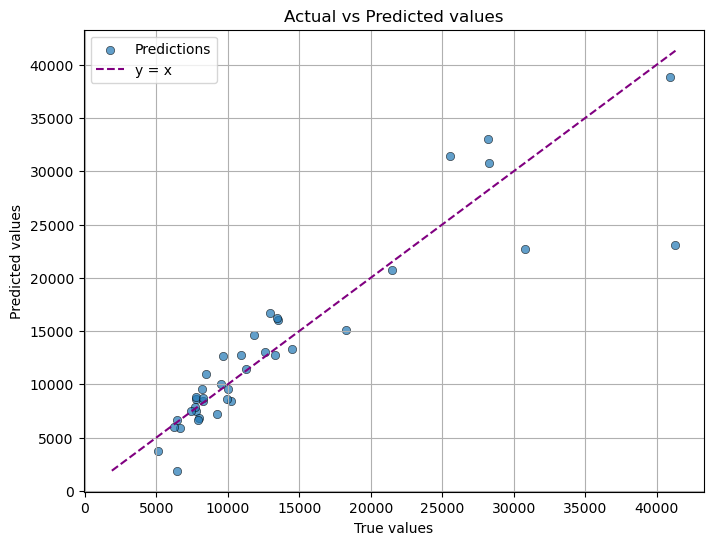

In [368]:
model = make_pipeline(
    PowerTransformer(),
    RobustScaler(),
    Ridge(alpha=1.0)  
)

# cross-validate the training
train_scores = cross_validate(model, X_train, y_train, cv=5, scoring='r2')
print(f"Training CV R²: {train_scores['test_score'].mean():.3f}")


model.fit(X_train, y_train)  
test_r2 = model.score(X_test, y_test)
print(f"Test R²: {test_r2:.3f}")


predicted = model.predict(X_test)
regression_report(predicted, y_test)


plot_actual_predicted(y_test, predicted)

### Visualization

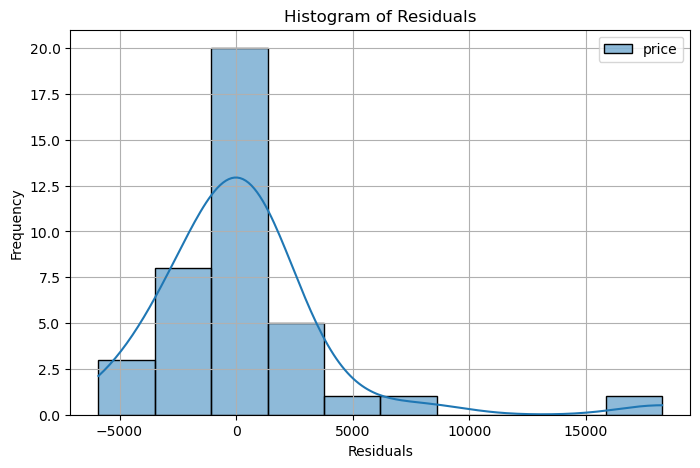

In [369]:
histogram_residuals(y_test, predicted)

This histogram indicates that the residuals follow a normal distribution (but has a little right skew to it) which is a good sign since it shows that the model captures all systematic patterns leaving only the white noise.

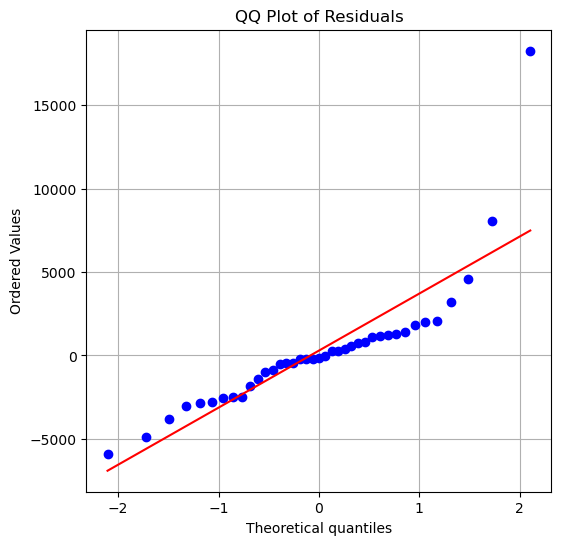

In [370]:
res = y_test.to_numpy().flatten() - predicted.flatten()
plot_qq(res)

The qq plot shows that the residuals follow the straight line, which validates our assumption that the residuals are normally distributed.

### Comparaison between the predicted prices and the actual prices

In [371]:
y_test_arr = y_test.to_numpy().flatten()
predicted_arr = predicted.flatten()

comparaison = pd.DataFrame({
    "Actual price: ":y_test_arr,
    "Predicted Price: ":predicted_arr
})

print(comparaison)

    Actual price:   Predicted Price: 
0          30760.0       22721.463773
1           9549.0        9989.998447
2          11850.0       14650.059874
3          28248.0       30747.163982
4           7799.0        7505.832097
5           7788.0        8658.265927
6           9258.0        7243.964697
7          10198.0        8397.306054
8           7775.0        8780.000041
9          13295.0       12721.669787
10          8238.0        8462.876125
11         18280.0       15062.483498
12          9988.0        9588.764400
13         40960.0       38879.969493
14          6488.0        6652.060792
15          5151.0        3721.377678
16         12629.0       13073.588512
17          8189.0        9574.220704
18          9960.0        8647.346008
19          8495.0       10975.528818
20         13499.0       16074.004713
21          8249.0        8740.459684
22          6479.0        1895.715147
23          6692.0        5880.565133
24         41315.0       23039.807964
25          

# Conclusion

* The linear regression model at first showed terrible prediction with negative R2 score, and this is because the features were collinear and had no linear relationship with the target.  

* After this, PCA was tried to lower the dimensionality thus delete the collinearity. However after the training and the cross validation the result showed overfitting with bad score. Which suggests that this approach is not suitable. 

* Finally, the approach that showed some improvement was transforming the features using the pipe line and the PowerTransformer transformation, that makes the data more linear.    
But in the end the approach that worked well with 82% R2 score is the Ridge regularization. Which means that for this type of data that shows non linearity the standard Linear Regression model doesn't work well, variation of this model along with the transformation of the features is the solution for better prediction.